In [1]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    silhouette_samples
)

from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

In [2]:
# 2. LOAD DATA

df = pd.read_parquet(r"clean_datasets/customer_features_clean.parquet")

print(df.head())

   customer_id municipality risk_rating onboarding_date  age  assets_total  \
0            1     Medellín         low      2024-03-06   20      9,644.53   
1            2      Armenia         low      2019-12-14   62     31,913.51   
2            4  Santa Marta      medium      2017-08-30   62     67,375.64   
3            5  Santa Marta         low      2019-04-02   53     27,237.00   
4            6   Valledupar         low      2023-01-21   30     37,064.28   

   liabilities_total  monthly_income  monthly_expenses  pep_flag  \
0           4,848.53        5,348.34          4,453.54         0   
1          25,856.24        3,575.39          1,502.09         0   
2          16,591.10        2,871.72          2,760.11         0   
3          13,887.45        8,846.98          6,561.25         0   
4          13,565.81        7,412.12          7,935.29         0   

   tx_count_credit  tx_count_debit  amount_sum_credit  amount_sum_debit  
0             0.08            0.08          10,8

In [3]:
# 3. SELECT RELEVANT VARIABLES

features = [
    'assets_total',
    'liabilities_total',
    'monthly_income',
    'monthly_expenses',
    'tx_count_credit',
    'tx_count_debit',
    'amount_sum_credit',
    'amount_sum_debit'
]

target = "risk_rating"

In [4]:
# 4. CREATE DATAFRAMES BY RISK RATING

risk_groups = {}

for risk in df[target].unique():

    risk_df = df[df[target] == risk].copy()

    risk_groups[risk] = risk_df

    print(f"\nRisk Rating: {risk}")
    print(f"Shape: {risk_df.shape}")


Risk Rating: low
Shape: (2591, 14)

Risk Rating: medium
Shape: (804, 14)

Risk Rating: high
Shape: (129, 14)


In [5]:
# 5. FUNCTION TO EVALUATE CLUSTERING MODELS

def evaluate_kmeans_models(data, k_range=range(2, 11)):

    inertias = []
    silhouette_scores = []
    ch_scores = []

    for k in k_range:

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = model.fit_predict(data)

        inertias.append(model.inertia_)

        silhouette_scores.append(
            silhouette_score(data, labels)
        )

        ch_scores.append(
            calinski_harabasz_score(data, labels)
        )

    return inertias, silhouette_scores, ch_scores

In [6]:
# 6. FUNCTION TO PLOT METRICS

def plot_clustering_metrics(
    k_range,
    inertias,
    silhouette_scores,
    ch_scores,
    risk_name
):

    fig, axes = plt.subplots(1, 3, figsize=(18,5))

    # ---------- Elbow ----------

    axes[0].plot(k_range, inertias, marker='o')

    axes[0].set_title(f"Elbow Method - {risk_name}")
    axes[0].set_xlabel("K")
    axes[0].set_ylabel("Inertia")

    # ---------- Silhouette ----------

    axes[1].plot(k_range, silhouette_scores, marker='o')

    axes[1].set_title(f"Silhouette Score - {risk_name}")
    axes[1].set_xlabel("K")
    axes[1].set_ylabel("Score")

    # ---------- Calinski-Harabasz ----------

    axes[2].plot(k_range, ch_scores, marker='o')

    axes[2].set_title(f"Calinski-Harabasz - {risk_name}")
    axes[2].set_xlabel("K")
    axes[2].set_ylabel("Score")

    plt.tight_layout()
    plt.show()


RISK RATING: low


c:\Users\jason\OneDrive\MCD\mcd.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\jason\OneDrive\MCD\mcd.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\jason\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jason\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._

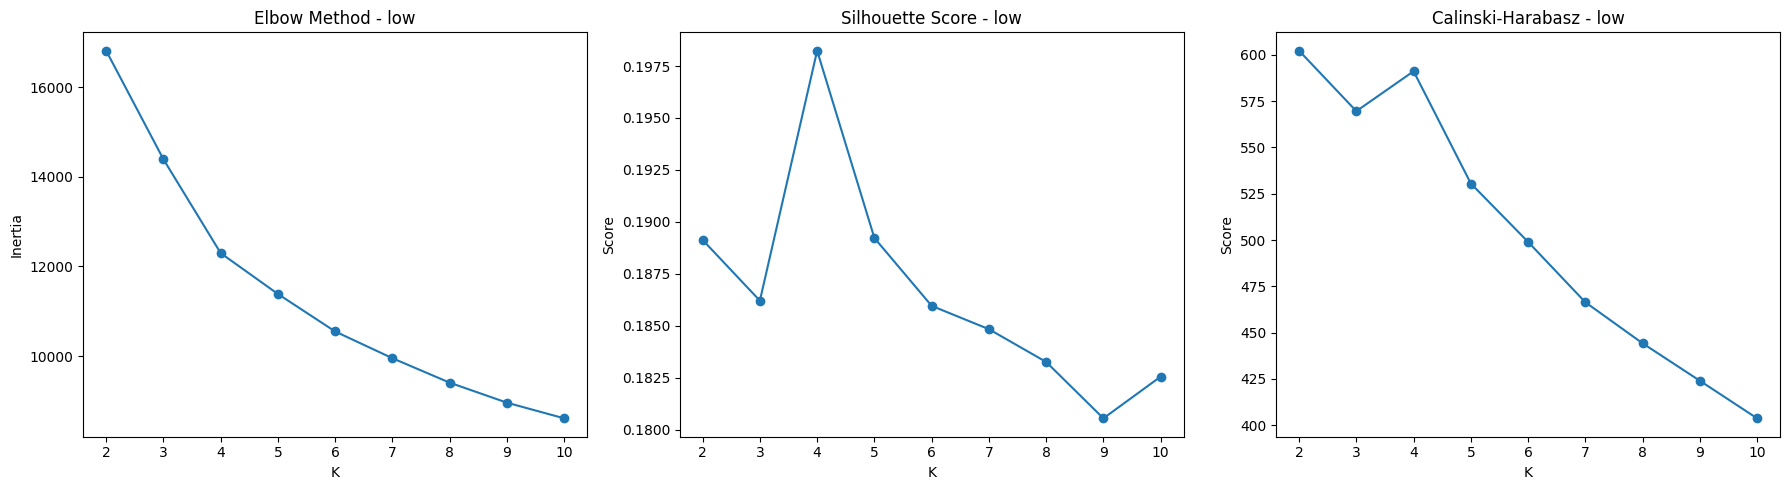


Best K selected: 4

Cluster Distribution (%)
cluster
1   34.97
2   26.94
3   20.26
0   17.83
Name: proportion, dtype: float64


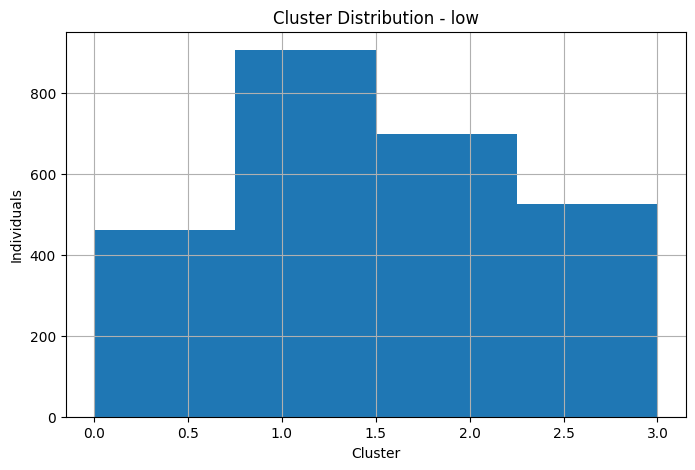


Silhouette Score: 0.1982


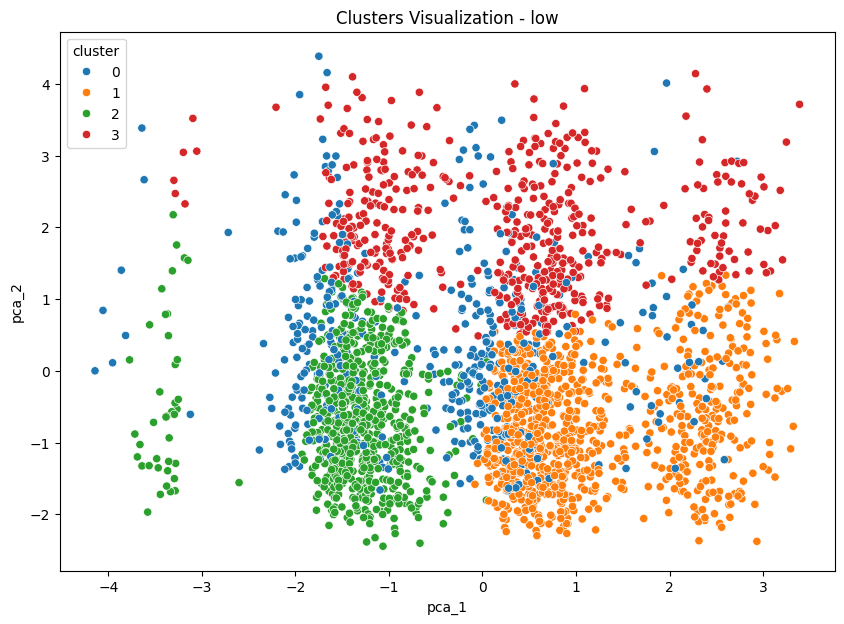


RISK RATING: medium


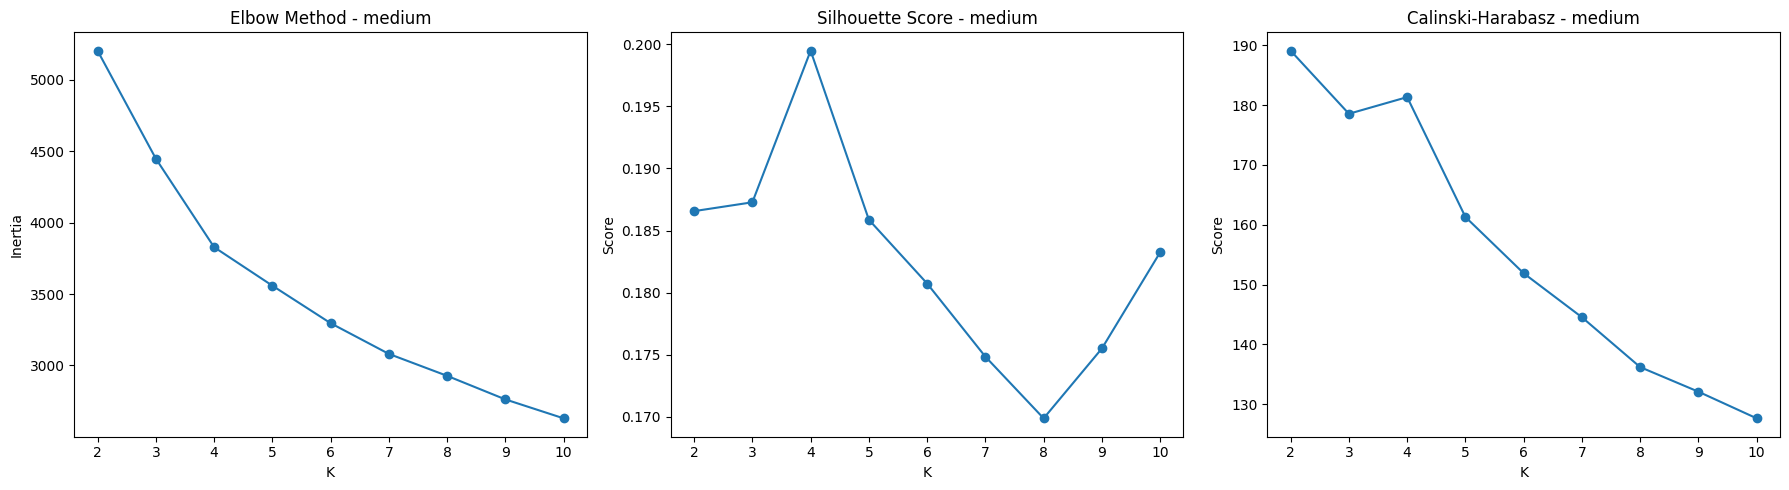


Best K selected: 4

Cluster Distribution (%)
cluster
2   35.32
1   30.47
3   17.54
0   16.67
Name: proportion, dtype: float64


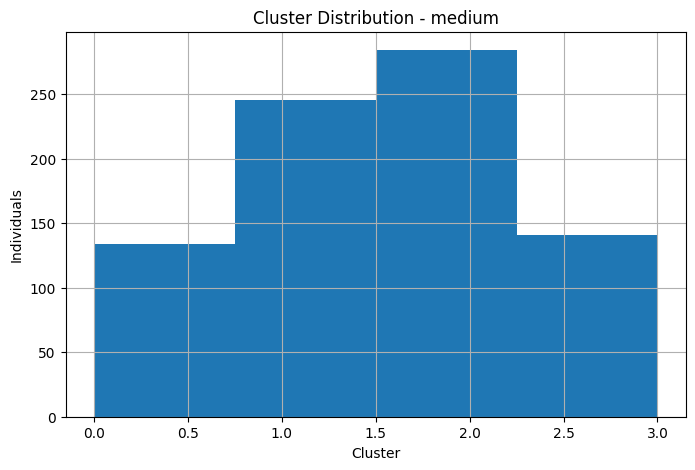


Silhouette Score: 0.1995


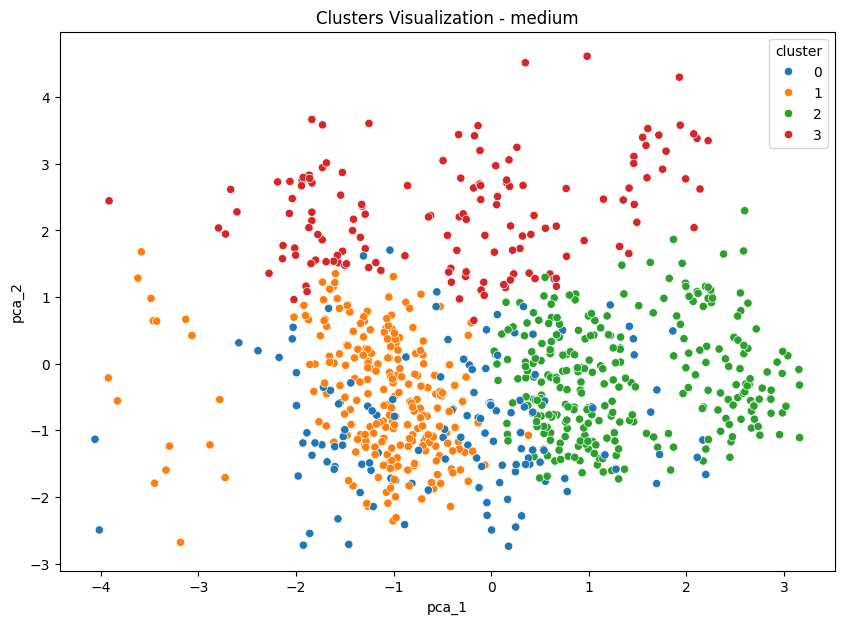


RISK RATING: high


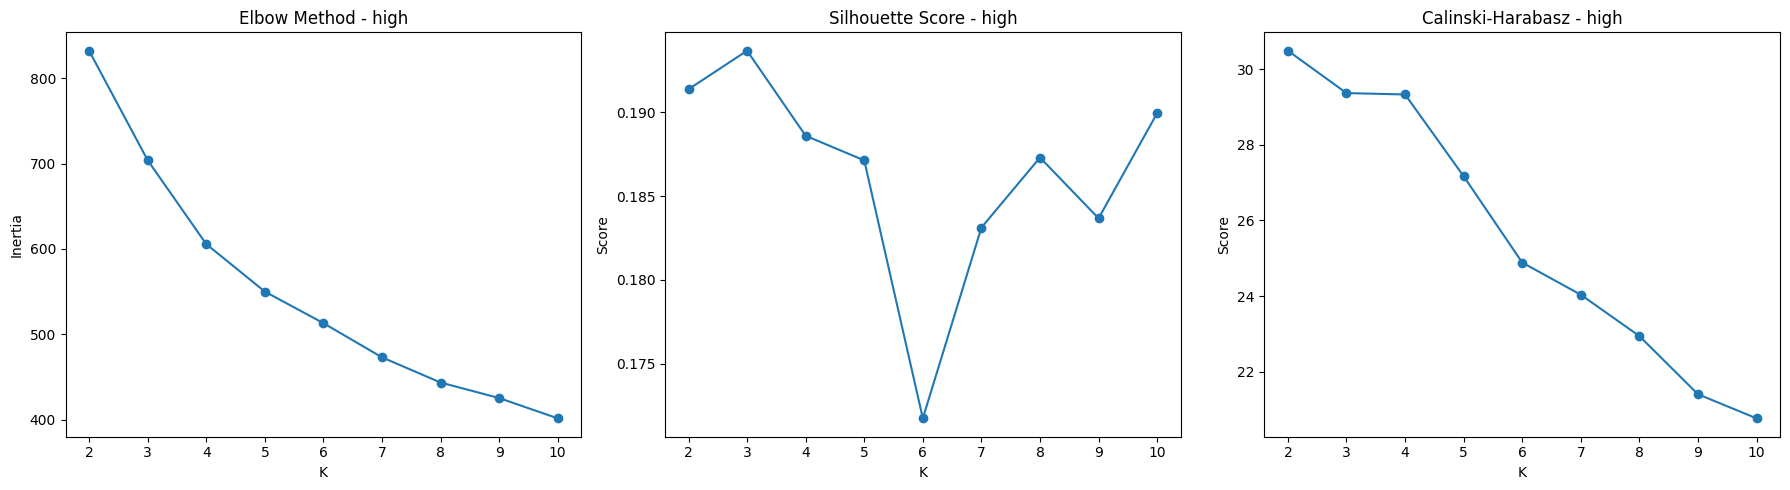


Best K selected: 3

Cluster Distribution (%)
cluster
1   46.51
2   29.46
0   24.03
Name: proportion, dtype: float64


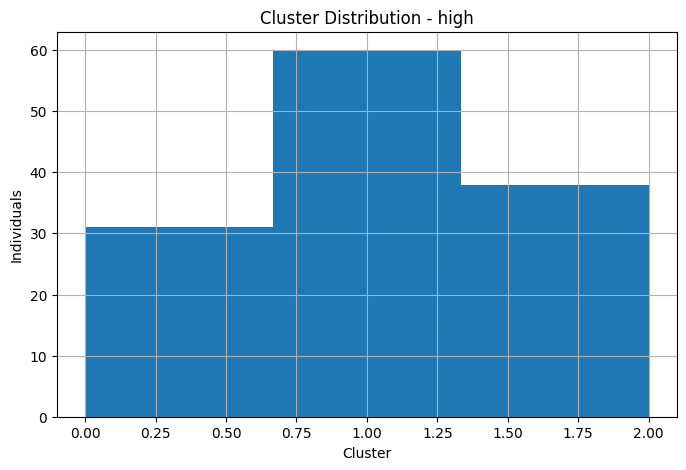


Silhouette Score: 0.1937


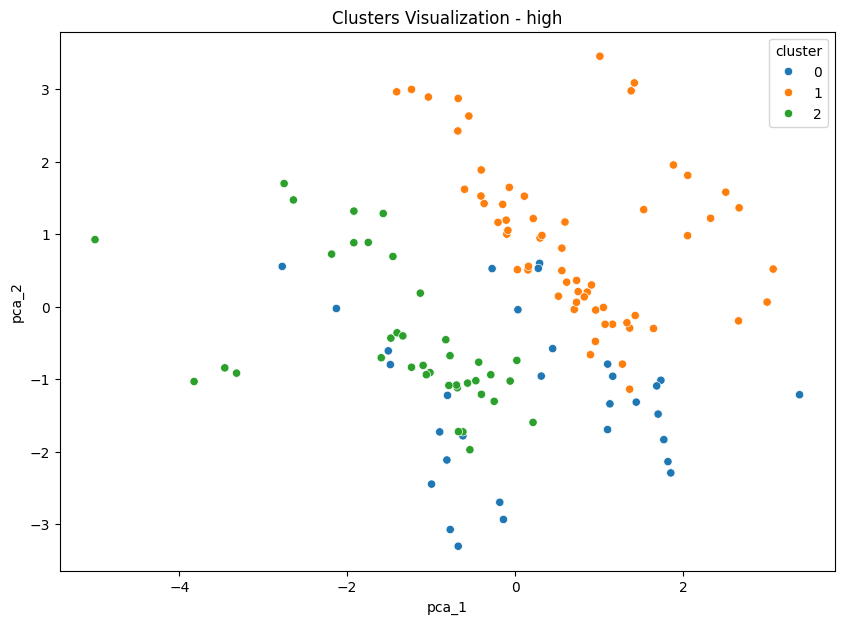

In [7]:
# 7. RUN ANALYSIS FOR EACH RISK RATING

cluster_profiles = []
cluster_individuals = []

for risk_name, risk_df in risk_groups.items():

    print("\n================================================")
    print(f"RISK RATING: {risk_name}")
    print("================================================")

    # =====================================================
    # SELECT FEATURES
    # =====================================================

    X = risk_df[features]

    # =====================================================
    # NORMALIZATION
    # =====================================================

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    # =====================================================
    # MODEL EVALUATION
    # =====================================================

    k_range = range(2, 11)

    inertias, silhouette_scores, ch_scores = (
        evaluate_kmeans_models(X_scaled, k_range)
    )

    # =====================================================
    # PLOT METRICS
    # =====================================================

    plot_clustering_metrics(
        k_range,
        inertias,
        silhouette_scores,
        ch_scores,
        risk_name
    )

    # =====================================================
    # BEST K
    # =====================================================

    best_k = k_range[
        np.argmax(silhouette_scores)
    ]

    print(f"\nBest K selected: {best_k}")

    # =====================================================
    # FINAL MODEL
    # =====================================================

    final_model = KMeans(
        n_clusters=best_k,
        random_state=42,
        n_init=10
    )

    clusters = final_model.fit_predict(X_scaled)

    risk_df["cluster"] = clusters

    # =====================================================
    # CLUSTER DISTRIBUTION
    # =====================================================

    cluster_distribution = (
        risk_df["cluster"]
        .value_counts(normalize=True) * 100
    )

    print("\nCluster Distribution (%)")
    print(cluster_distribution)

    # =====================================================
    # HISTOGRAM OF CLUSTERS
    # =====================================================

    plt.figure(figsize=(8,5))

    risk_df["cluster"].hist(
        bins=best_k
    )

    plt.title(
        f"Cluster Distribution - {risk_name}"
    )

    plt.xlabel("Cluster")
    plt.ylabel("Individuals")

    plt.show()

    # =====================================================
    # SILHOUETTE SCORE
    # =====================================================

    sil_score = silhouette_score(
        X_scaled,
        clusters
    )

    print(f"\nSilhouette Score: {sil_score:.4f}")

    # =====================================================
    # PCA FOR VISUALIZATION
    # =====================================================

    pca = PCA(n_components=2)

    X_pca = pca.fit_transform(X_scaled)

    risk_df["pca_1"] = X_pca[:,0]
    risk_df["pca_2"] = X_pca[:,1]

    # =====================================================
    # SCATTER PLOT
    # =====================================================

    plt.figure(figsize=(10,7))

    sns.scatterplot(
        data=risk_df,
        x="pca_1",
        y="pca_2",
        hue="cluster",
        palette="tab10"
    )

    plt.title(
        f"Clusters Visualization - {risk_name}"
    )

    plt.show()

    # =====================================================
    # SUBSEGMENTATION
    # =====================================================

    largest_cluster_pct = cluster_distribution.max()

    if largest_cluster_pct > 50:

        print("\nSubsegmentation required.")

        largest_cluster = (
            cluster_distribution.idxmax()
        )

        sub_df = risk_df[
            risk_df["cluster"] == largest_cluster
        ].copy()

        X_sub = sub_df[features]

        X_sub_scaled = scaler.fit_transform(X_sub)

        sub_model = KMeans(
            n_clusters=2,
            random_state=42,
            n_init=10
        )

        subclusters = sub_model.fit_predict(
            X_sub_scaled
        )

        sub_df["subcluster"] = subclusters

        # Merge back

        risk_df = risk_df.merge(
            sub_df[
                ["customer_id", "subcluster"]
            ],
            on="customer_id",
            how="left"
        )

        # Histogram

        plt.figure(figsize=(8,5))

        risk_df["subcluster"].value_counts().plot(
            kind="bar"
        )

        plt.title(
            f"Subcluster Distribution - {risk_name}"
        )

        plt.xlabel("Subcluster")
        plt.ylabel("Individuals")

        plt.show()

    # =====================================================
    # CLUSTER PROFILE TABLE
    # =====================================================

    profile_table = (
        risk_df
        .groupby("cluster")[features]
        .mean()
        .round(2)
    )

    profile_table["risk_rating"] = risk_name

    cluster_profiles.append(
        profile_table.reset_index()
    )

    # =====================================================
    # INDIVIDUALS TABLE
    # =====================================================

    individuals_table = risk_df[
        [
            "customer_id",
            "risk_rating",
            "cluster"
        ]
    ].copy()

    if "subcluster" in risk_df.columns:

        individuals_table["subcluster"] = (
            risk_df["subcluster"]
        )

    cluster_individuals.append(
        individuals_table
    )

In [8]:
# 8. CONSOLIDATE RESULTS

df_cluster_profiles = pd.concat(
    cluster_profiles,
    ignore_index=True
)

df_cluster_individuals = pd.concat(
    cluster_individuals,
    ignore_index=True
)

In [9]:
# 9. SHOW RESULTS

print("\n==============================")
print("CLUSTER PROFILES")
print("==============================")

print(df_cluster_profiles.head())

print("\n==============================")
print("CLUSTER INDIVIDUALS")
print("==============================")

print(df_cluster_individuals.head())


CLUSTER PROFILES
   cluster  assets_total  liabilities_total  monthly_income  monthly_expenses  \
0        0    139,263.95          66,178.13        8,393.77          6,055.72   
1        1     43,329.12          19,908.65        6,636.25          4,719.54   
2        2     45,508.45          20,262.96        6,590.95          4,792.02   
3        3     51,647.48          23,688.76       15,959.37         12,147.55   
4        0    143,390.52          66,535.49        7,177.07          5,184.75   

   tx_count_credit  tx_count_debit  amount_sum_credit  amount_sum_debit  \
0             0.14            0.14         366,508.43        454,469.40   
1             0.19            0.19         446,441.68        622,356.48   
2             0.08            0.08         290,367.49        406,000.66   
3             0.15            0.14         358,630.34        562,018.84   
4             0.14            0.14         509,267.22        667,206.99   

  risk_rating  
0         low  
1         lo

In [10]:
# 10. SAVE RESULTS

df_cluster_profiles.to_excel(
    "clusters/cluster_profiles.xlsx",
    index=False
)

df_cluster_individuals.to_excel(
    "clusters/cluster_individuals.xlsx",
    index=False
)

print("\nFiles saved successfully.")


Files saved successfully.
